# Final Submission

**ISIC 2024 – Skin Cancer Detection with 3D-TBP**

This notebook reproduces the final competition submission using the pretrained models generated during the previous stages of the project.

The inference pipeline combines:

- ResNet18
- EfficientNet-B0
- CatBoost
- Logistic Regression stacking

to generate the final malignancy probability for every test image.

## Inference Pipeline

The submission is generated according to the following sequence:

1. Load the competition test dataset.
2. Generate predictions using the CatBoost metadata model.
3. Generate predictions using the ResNet18 image model.
4. Generate predictions using the EfficientNet-B0 image model.
5. Standardize the prediction probabilities.
6. Apply the trained Logistic Regression stacker.
7. Export the final submission file.

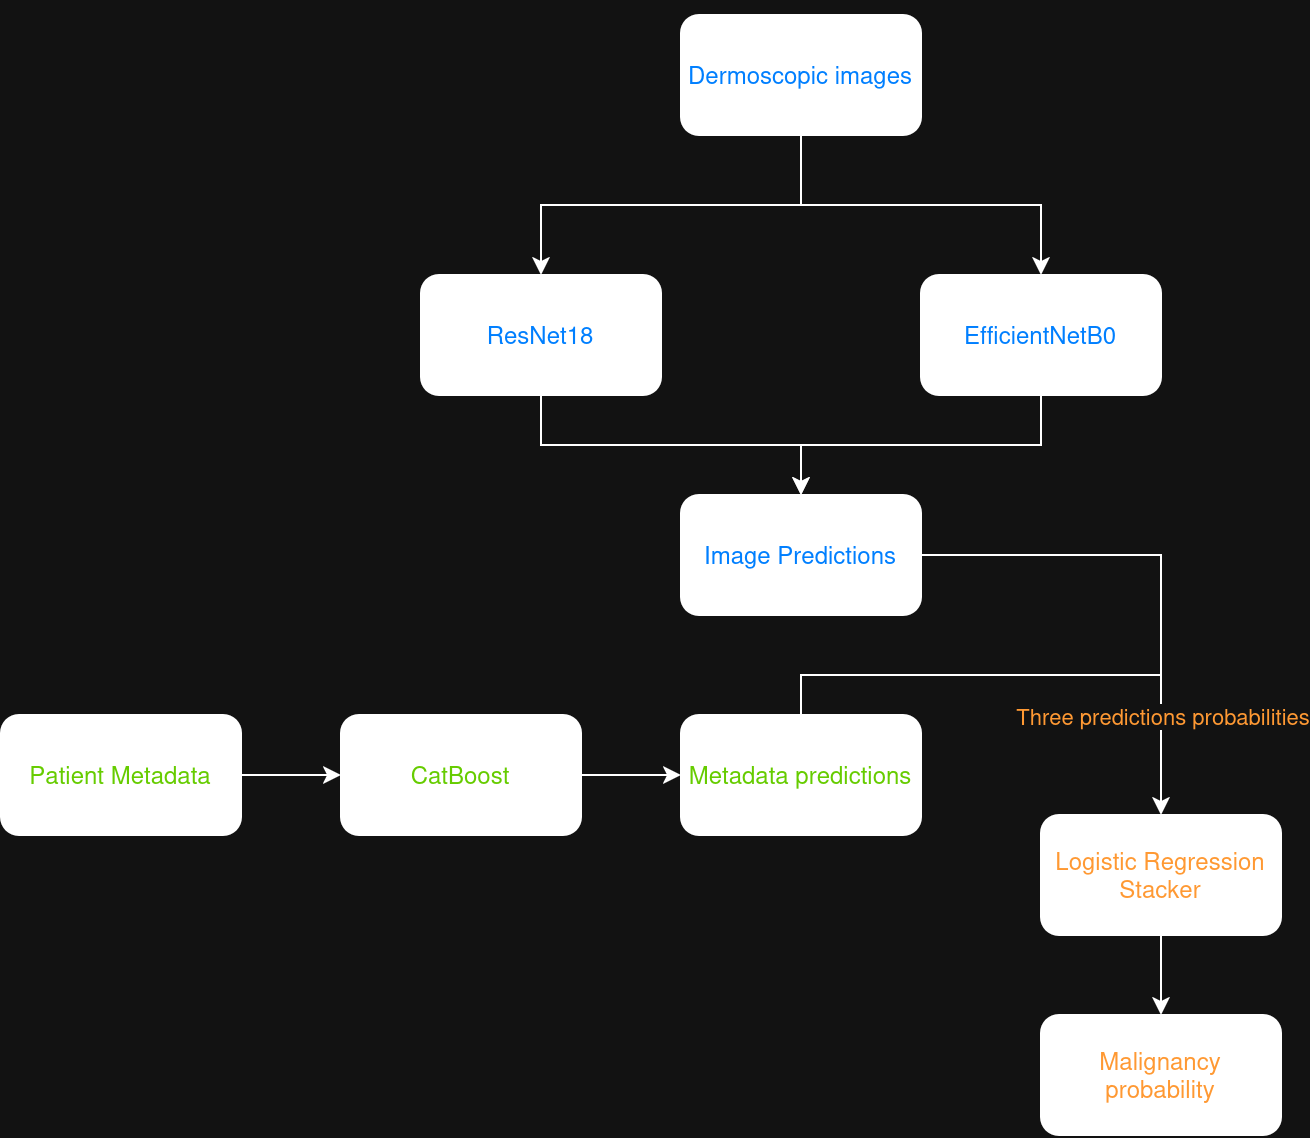

## Configuration

Define the dataset locations together with the paths to the pretrained models used during inference.

In [ ]:
# =========================
# Competition paths
# =========================

TEST_CSV = "/kaggle/input/competitions/isic-2024-challenge/test-metadata.csv"
TEST_HDF5 = "/kaggle/input/competitions/isic-2024-challenge/test-image.hdf5"
SAMPLE_SUBMISSION_CSV = "/kaggle/input/competitions/isic-2024-challenge/sample_submission.csv"


# =========================
# Image model
# =========================

EFF_MODEL_DIR = "/kaggle/input/datasets/wagneraugustoaff/isic2024-efficientnetb0-1fold"
RSN_MODEL_DIR = "/kaggle/input/datasets/wagneraugustoaff/isic2024-resnet18-5fold-baseline"

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
PIN_MEMORY = True


# =========================
# CatBoost model
# =========================

CAT_MODEL_DIR = "/kaggle/input/datasets/wagneraugustoaff/isic2024-catboost-5fold-baseline/5fold-cv-models"

FEATURES_PATH = f"{CAT_MODEL_DIR}/features.json"
N_FOLDS = 5

## Imports

Import the required libraries together with the project modules responsible for preprocessing, inference, and submission generation.

In [ ]:
import sys
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [ ]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
CODE_PATH = "/kaggle/input/isic2024-code/src/image"
sys.path.append(CODE_PATH)

from image_model import ISICModelRsn
from image_model import ISICModelEff
from image_dataset import ISICDataset
from image_inference import predict

CODE_PATH = "/kaggle/input/isic2024-code/src/cat"
sys.path.append(CODE_PATH)

from cat_dataset import prepare_data
from cat_inference import predict_all_folds

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

## Load Test Dataset

Load the ISIC 2024 competition test metadata and prepare the corresponding image dataset for inference.

In [ ]:
test_df = pd.read_csv(TEST_CSV)

## Metadata Model Inference

Generate malignancy probabilities using the CatBoost model trained on the complete metadata dataset.

In [ ]:
X_test, _ = prepare_data(
    test_df,
    training=False,
)

with open(FEATURES_PATH) as f:
    feature_info = json.load(f)

expected = feature_info["features"]

extra = set(X_test.columns) - set(expected)

if extra:
    print(f"Warning: ignoring {len(extra)} unexpected features:")
    print(sorted(extra))

for feature in expected:
    if feature not in X_test.columns:
        print(f"Adding missing feature: {feature}")
        X_test[feature] = np.nan

X_test = X_test[expected]

In [ ]:
predictions_cat = predict_all_folds(
    X=X_test,
    model_dir=CAT_MODEL_DIR,
    n_folds=N_FOLDS,
)

In [ ]:
valid_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_dataset = ISICDataset(
    dataframe=test_df,
    image_path=TEST_HDF5,
    transform=valid_transform,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

## ResNet18 Inference

Load the pretrained ResNet18 model and generate prediction probabilities for the test images.

In [ ]:
all_predictions = []

model = ISICModelRsn(pretrained=False).to(device)

checkpoint = torch.load(
    f"{RSN_MODEL_DIR}/resnet_final.pth",
    map_location=device,
)

model.load_state_dict(checkpoint)

model.eval()

predictions = predict(
    model=model,
    dataloader=test_loader,
    device=device,
)

all_predictions.append(predictions)

predictions_rsn = np.mean(
    all_predictions,
    axis=0,
)

## EfficientNet-B0 Inference

Load the pretrained EfficientNet-B0 model and generate prediction probabilities for the test images.

In [ ]:
all_predictions = []

model = ISICModelEff(pretrained=False).to(device)

checkpoint = torch.load(
    f"{EFF_MODEL_DIR}/efficientnet_final.pth",
    map_location=device,
)

model.load_state_dict(checkpoint)

model.eval()

predictions = predict(
    model=model,
    dataloader=test_loader,
    device=device,
)

all_predictions.append(predictions)

predictions_eff = np.mean(
    all_predictions,
    axis=0,
)

## Multimodal Stacking

Combine the prediction probabilities produced by the three base models using the trained Logistic Regression meta-model.

In [ ]:
import joblib

meta_model = joblib.load("/kaggle/input/datasets/wagneraugustoaff/isic-2024-stacking-models/logistic_regression/logistic_regression.pkl")

# Match the feature order used during stacker training.
X_test = pd.DataFrame({
    "resnet": predictions_rsn,
    "efficientnet": predictions_eff,
    "catboost": predictions_cat,
})

final_pred = meta_model.predict_proba(X_test)[:, 1]

In [ ]:
# final_pred = (
#     predictions_cat +
#     predictions_rsn +
#     predictions_eff
# ) / 3.0

In [ ]:
# W_RESNET = 0.20
# W_EFFICIENTNET = 0.45
# W_CATBOOST = 0.35

# final_pred = (
#     W_RESNET * predictions_rsn 
#     + W_EFFICIENTNET * predictions_eff
#     + W_CATBOOST * predictions_cat
# )

## Generate Submission

Create the submission file required by the Kaggle competition using the predicted malignancy probabilities.

In [ ]:
submission = pd.DataFrame({

    "isic_id": test_df["isic_id"],

    "target": final_pred,

})

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False,
)

## Summary

The generated submission represents the complete multimodal pipeline proposed in this project, combining image-based and metadata-based models through Logistic Regression stacking.

The generated `submission.csv` file is ready for upload to the Kaggle ISIC 2024 competition.